<a href="https://colab.research.google.com/github/MichalSlowakiewicz/Stochastic-Simulations/blob/master/Zadanie_5_4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

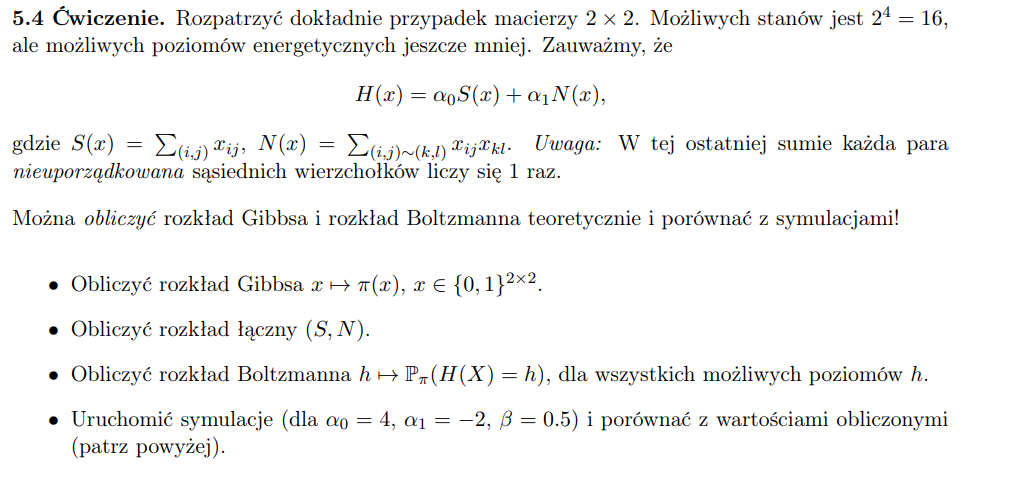

## Analytical Solution for 2x2 Model
---

For a $2 \times 2$ grid, the state space $\mathcal{X} = \{0, 1\}^{2 \times 2}$ contains exactly $2^4 = 16$ possible configurations.

The energy is defined as $H(x) = 4S(x) - 2N(x)$ (for parameters introduced in previous exercise), where $S$ is the sum of ones and $N$ is the number of pairs of ones. By enumerating all 16 states, we can group them by their statistics $(S, N)$:

| State Description | Permutations | $S$ (1s) | $N$ (Pairs) | Energy $H$ |
| :--- | :---: | :---: | :---: | :---: |
| Empty grid | 1 | 0 | 0 | **0** |
| Single '1' | 4 | 1 | 0 | **4** |
| Two '1's (Adjacent) | 4 | 2 | 1 | **6** |
| Two '1's (Diagonal) | 2 | 2 | 0 | **8** |
| Three '1's | 4 | 3 | 2 | **8** |
| Four '1's | 1 | 4 | 4 | **8** |


### Theoretical Distributions ($\beta = 0.5$)
The non-normalized weights for the Gibbs distribution are $W(x) = \exp(-0.5 \cdot H(x))$.
Let $Z$ be the sum of weights of all 16 states:
$$Z = 1 \cdot e^{0} + 4 \cdot e^{-2} + 4 \cdot e^{-3} + 7 \cdot e^{-4} \approx 1.8687$$

From this, we can define:
1. **Gibbs Distribution $\pi(x)$:** The probability of a specific matrix $x$ is $\frac{\exp(-0.5 \cdot H(x))}{Z}$.
2. **Joint Distribution $P(S, N)$:** for example: $P(S=2, N=1) = \frac{4 \cdot e^{-3}}{Z}$.
3. **Boltzmann Distribution $P(H=h)$:** The probability of observing a specific energy level $h$:
   * $P(H=0) = 1/Z \approx 53.51\%$
   * $P(H=4) = 4e^{-2}/Z \approx 28.97\%$
   * $P(H=6) = 4e^{-3}/Z \approx 10.66\%$
   * $P(H=8) = 7e^{-4}/Z \approx 6.86\%$

## Simulations
---

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import itertools

In [2]:
# setup
alpha_0 = 4.0
alpha_1 = -2.0
beta = 0.5

In [3]:
# helper functions
def calc_S(x):
    return np.sum(x)

def calc_N(x):
    # sum of pairs of ones for 2x2
    return (x[0,0]*x[0,1] + x[1,0]*x[1,1] +
            x[0,0]*x[1,0] + x[0,1]*x[1,1])

def calc_H(x):
    return alpha_0 * calc_S(x) + alpha_1 * calc_N(x)

In [6]:
# generating all possible 16 matricies 2x2
states_1d = list(itertools.product([0, 1], repeat=4))
states_2d = [np.array(s).reshape(2, 2) for s in states_1d]

# dictionary for saving results
H_weights = {0: 0, 4: 0, 6: 0, 8: 0}
Z = 0.0

print("Theoretical results:")
for x in states_2d:
    h = calc_H(x)
    weight = np.exp(-beta * h)
    H_weights[h] += weight
    Z += weight

print(f"Z = {Z:.4f}")
print("Boltzmann distribution P(H=h):")
P_H_theo = {}
for h in [0, 4, 6, 8]:
    P_H_theo[h] = H_weights[h] / Z
    print(f"P(H={h}) = {P_H_theo[h]:.4f} ({P_H_theo[h]*100:.2f}%)")

Theoretical results:
Z = 1.8687
Boltzmann distribution P(H=h):
P(H=0) = 0.5351 (53.51%)
P(H=4) = 0.2897 (28.97%)
P(H=6) = 0.1066 (10.66%)
P(H=8) = 0.0686 (6.86%)


In [7]:
# simulations with Gibbs sampler
np.random.seed(42)
d = 2

# initialization with padding
X = np.zeros((d + 2, d + 2), dtype=int)
X[1:-1, 1:-1] = np.random.binomial(1, 0.5, size=(d, d))

n = 20000
burn_in = 2000
H_history = []

# analogously as in previous excercise
for _ in range(n):
    i_coords = np.random.randint(1, d + 1, size=d * d)
    j_coords = np.random.randint(1, d + 1, size=d * d)

    for i, j in zip(i_coords, j_coords):
        z = X[i-1, j] + X[i+1, j] + X[i, j-1] + X[i, j+1]
        delta_H = alpha_0 + alpha_1 * z
        prob_1 = 1.0 / (1.0 + np.exp(beta * delta_H))
        X[i, j] = np.random.binomial(1, prob_1)

    # calculating H
    core = X[1:-1, 1:-1]
    S = np.sum(core)
    N_val = (core[0,0]*core[0,1] + core[1,0]*core[1,1] +
             core[0,0]*core[1,0] + core[0,1]*core[1,1])
    H = alpha_0 * S + alpha_1 * N_val
    H_history.append(H)

# deleting pre-burnin
H_samples = np.array(H_history[burn_in:])

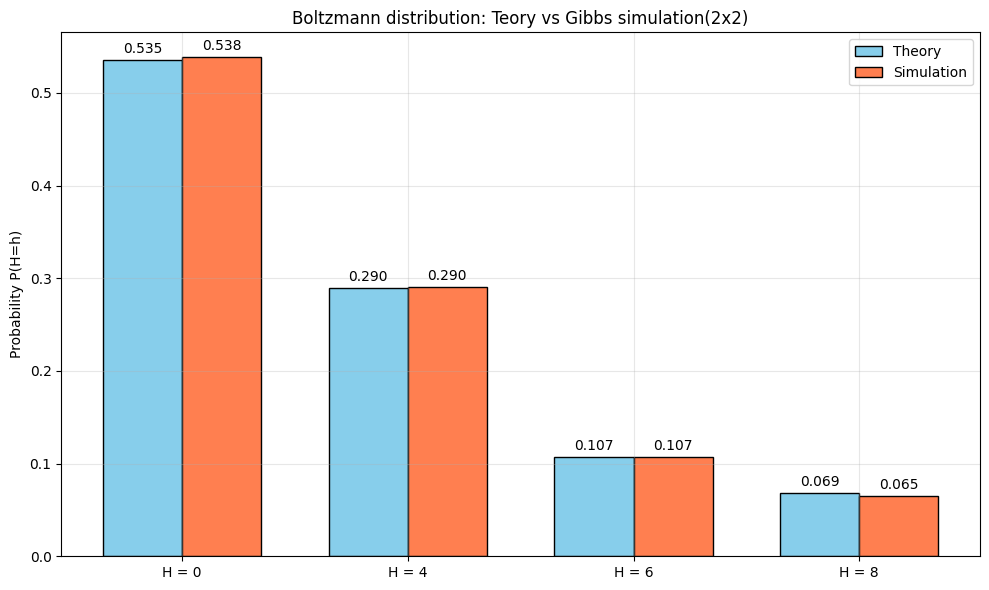

In [10]:
# visualizations

# calculating empirical frequency
P_H_mcmc = {h: np.mean(H_samples == h) for h in [0, 4, 6, 8]}

# plotting
labels = ['H = 0', 'H = 4', 'H = 6', 'H = 8']
theo_vals = [P_H_theo[h] for h in [0, 4, 6, 8]]
mcmc_vals = [P_H_mcmc[h] for h in [0, 4, 6, 8]]

x = np.arange(len(labels))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))
rects1 = ax.bar(x - width/2, theo_vals, width, label='Theory', color='skyblue', edgecolor='black')
rects2 = ax.bar(x + width/2, mcmc_vals, width, label='Simulation', color='coral', edgecolor='black')

ax.set_ylabel('Probability P(H=h)')
ax.set_title('Boltzmann distribution: Teory vs Gibbs simulation(2x2)')
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.legend()


def autolabel(rects):
    for rect in rects:
        height = rect.get_height()
        ax.annotate(f'{height:.3f}',
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 3),
                    textcoords="offset points",
                    ha='center', va='bottom')

autolabel(rects1)
autolabel(rects2)

plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()